# Moon Rover MPC Testing

In [1]:
%matplotlib ipympl

import jax
jax.config.update("jax_enable_x64", True)

In [2]:
import functools
import jax.numpy as jnp
import numpy as np
import tqdm
import pandas as pd
import control as ct

import matplotlib.pyplot as plt

import exp_mpc.stewart_min.siso as siso
import exp_mpc.stewart_min.mpc_spec as mpc_spec
import exp_mpc.stewart_min.opt as opt
import exp_mpc.stewart_min.viz as viz
import exp_mpc.stewart_min.mp_mpl as mp_mpl

In [3]:
limits = mpc_spec.MPCLimits()
spec = mpc_spec.MPCSpec()

In [4]:
# load data
def load_clean_references(file_path: str) -> tuple[jax.Array, jax.Array]:
    data = np.array(pd.read_hdf(file_path))
    return data[:, 1:4], data[:, 4:]

# file_path = "../../data/clean_00_sms_drive.hdf"
# file_path = "../../data/clean_specific-forces-standard-road-v2.hdf"
file_path = "../../data/clean_specific-forces-lander_motion_redes_manual.hdf"
# file_path = "../../data/clean_specific-forces-lander_motion_redes_auto.hdf"
acc_ref, omega_ref = load_clean_references(file_path)

# use 100 Hz sampling
acc_ref = acc_ref[::2]
omega_ref = omega_ref[::2]

assert acc_ref.shape[0] == omega_ref.shape[0]
assert acc_ref.shape[1] == 3
assert omega_ref.shape[1] == 3

# filt (butter)
s = ct.tf("s") / (2 * np.pi * 0.5)
butter = siso.DiscreteSISO.cont2discrete(1 / (1 + 2 * s + 2 * s**2 + s**3), dt=spec.dt, method="bilinear")
ABCD = [butter.A, butter.B, butter.C, butter.D]

def butter_int(u):
    assert len(u.shape) == 1
    one = np.ones(ABCD[0].shape[0])
    x0 = siso.obs_x0(*ABCD, y=one * u[0], u=one * u[0])
    return siso.lti_int(*ABCD, x0, u)[1]

acc_ref = jnp.array([butter_int(u) for u in acc_ref.T]).T
omega_ref = jnp.array([butter_int(u) for u in omega_ref.T]).T

In [5]:
begin = 0
# num_steps = 100 * 60 * 3
num_steps = acc_ref.shape[0]
n = 200  # horizon

In [6]:
# cost setup
# weights = mpc_spec.ExpWeights(
#     lin_dyn=jnp.ones(3) * 1e4,
#     omega=jnp.ones(3) * 1e5,
#     control=jnp.ones(6) * 1e-1,
#     alpha_acc=jnp.array([0.0]),
#     alpha_omega=jnp.array([4.0]),
# )
weights = mpc_spec.ExpWeights(
    lin_dyn=jnp.ones(3) * 1e5,
    omega=jnp.ones(3) * 5e5,
    control=jnp.ones(6) * 1e-1,
    alpha_acc=jnp.array([1.0]),
    alpha_omega=jnp.array([1.0]),
)
limits = mpc_spec.MPCLimits()
spec = mpc_spec.MPCSpec.init_weight_margins(weights, limits, max_iter=2, max_ls=2, use_terminal=True)
train_step = functools.partial(opt.train_step_with_cost, spec=spec, use_scipy=False)

In [ ]:
# run setup
train_state = opt.TrainState.zero_init(spec, mpc_spec.moon_gravity[-1])  #acc_ref[0, 3]
train_list = []
times = []
res_list = []

In [8]:
# precompile
aref = jnp.tile(acc_ref[0], reps=(n, 1))
oref = jnp.tile(omega_ref[0], reps=(n, 1))
print(train_step(aref, oref, train_state)[-1])  # compile + run-time

3.0720338821411133


In [9]:
# run
for i in tqdm.tqdm(range(num_steps - n)):
    aref = jnp.tile(acc_ref[begin + i], reps=(n, 1))
    oref = jnp.tile(omega_ref[begin + i], reps=(n, 1))
    # aref = acc_ref[begin + i: begin + i + n]
    # oref = omega_ref[begin + i: begin + i + n]
    train_state, res, t_tot = train_step(aref, oref, train_state)
    train_list.append(train_state)
    res_list.append(res)
    times.append(t_tot)


100%|██████████| 14259/14259 [01:01<00:00, 233.59it/s]


In [10]:
# # run zero for a minute
# for i in tqdm.tqdm(range(200 * 60)):
#     aref = jnp.tile(const.moon_gravity, reps=(n, 1))
#     oref = jnp.tile(jnp.zeros(3), reps=(n, 1))
#     train_state, sol, res, t_tot = train_step(aref, oref, train_state)
#     train_list.append(train_state)
#     sol_list.append(sol)
#     res_list.append(res)
#     times.append(t_tot)

In [11]:
freqs = 1.0 / np.array(times)
print(f"{float(np.min(freqs)):.2f}, {float(np.max(freqs)):.2f}, {float(np.mean(freqs)):.2f}, {float(np.std(freqs)):.2f}")

138.80, 268.61, 247.84, 12.05


In [13]:
plt.close("all")

In [14]:
plot_size = len(train_list)
trajectory = train_list[:plot_size]
references = {
    "xyz-acceleration": jnp.array(acc_ref[begin: begin + plot_size]),
    "angular-velocity": jnp.array(omega_ref[begin: begin + plot_size]),
}

In [15]:
jnp.degrees(jnp.mean(omega_ref[3000: 11000, 1])) * (110 - 30)

Array(124.2165494, dtype=float64)

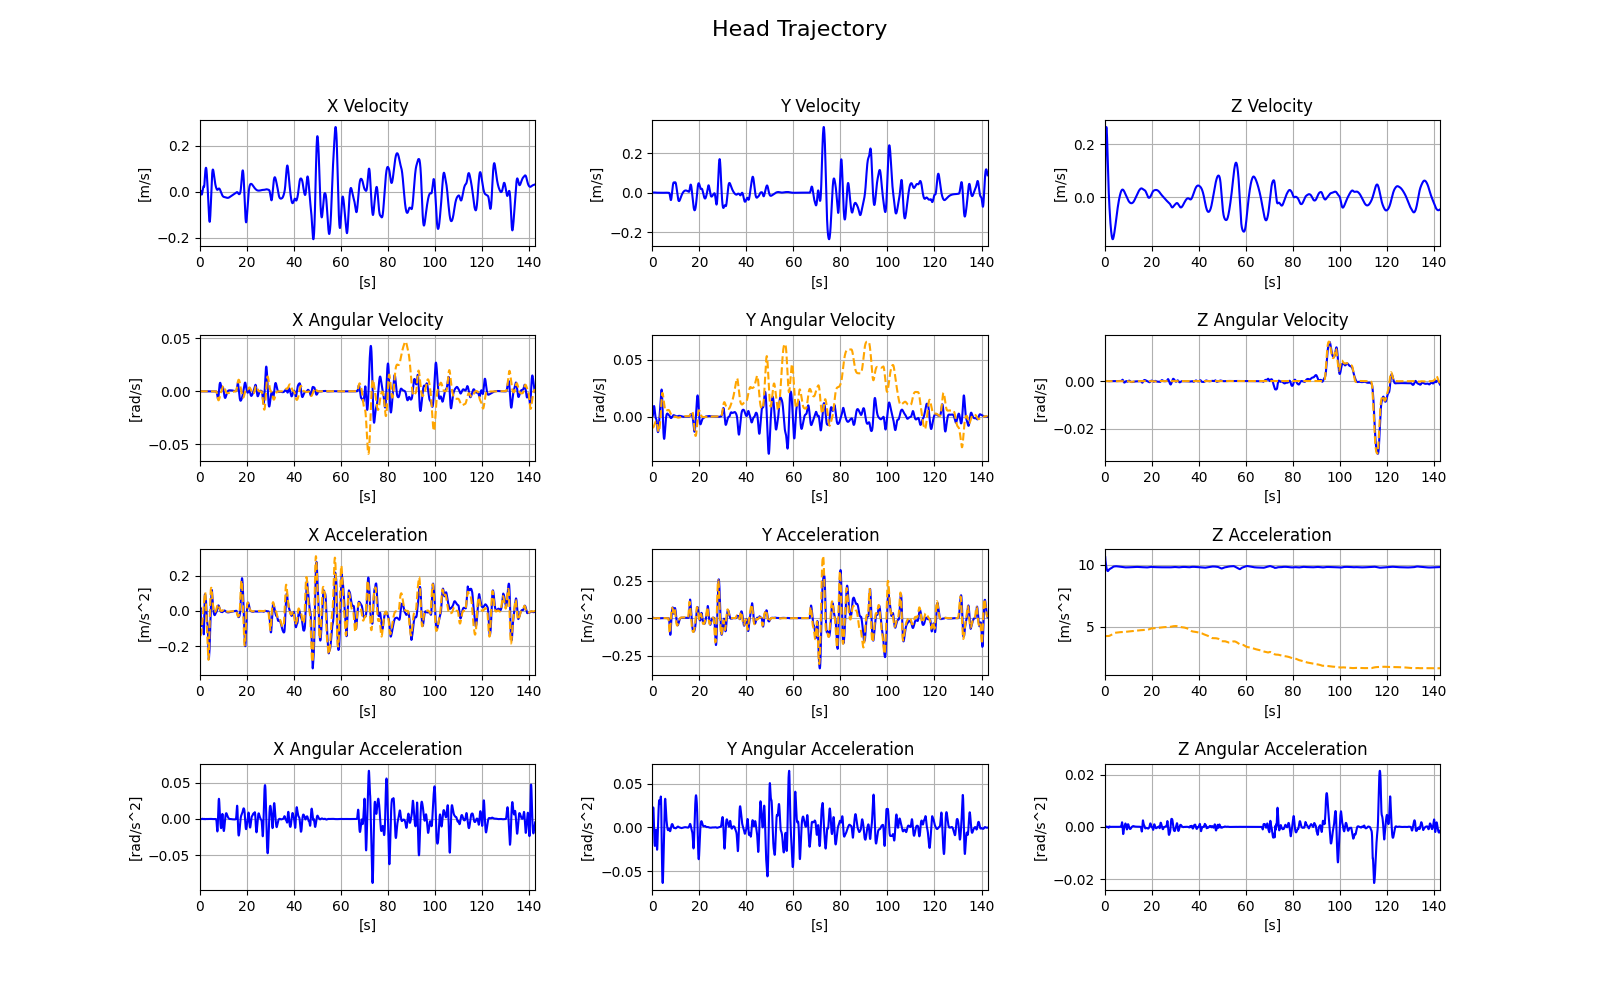

In [16]:
mpc_human_fig = viz.plot_human_trajectory(trajectory=trajectory, limits=limits, spec=spec, references=references)

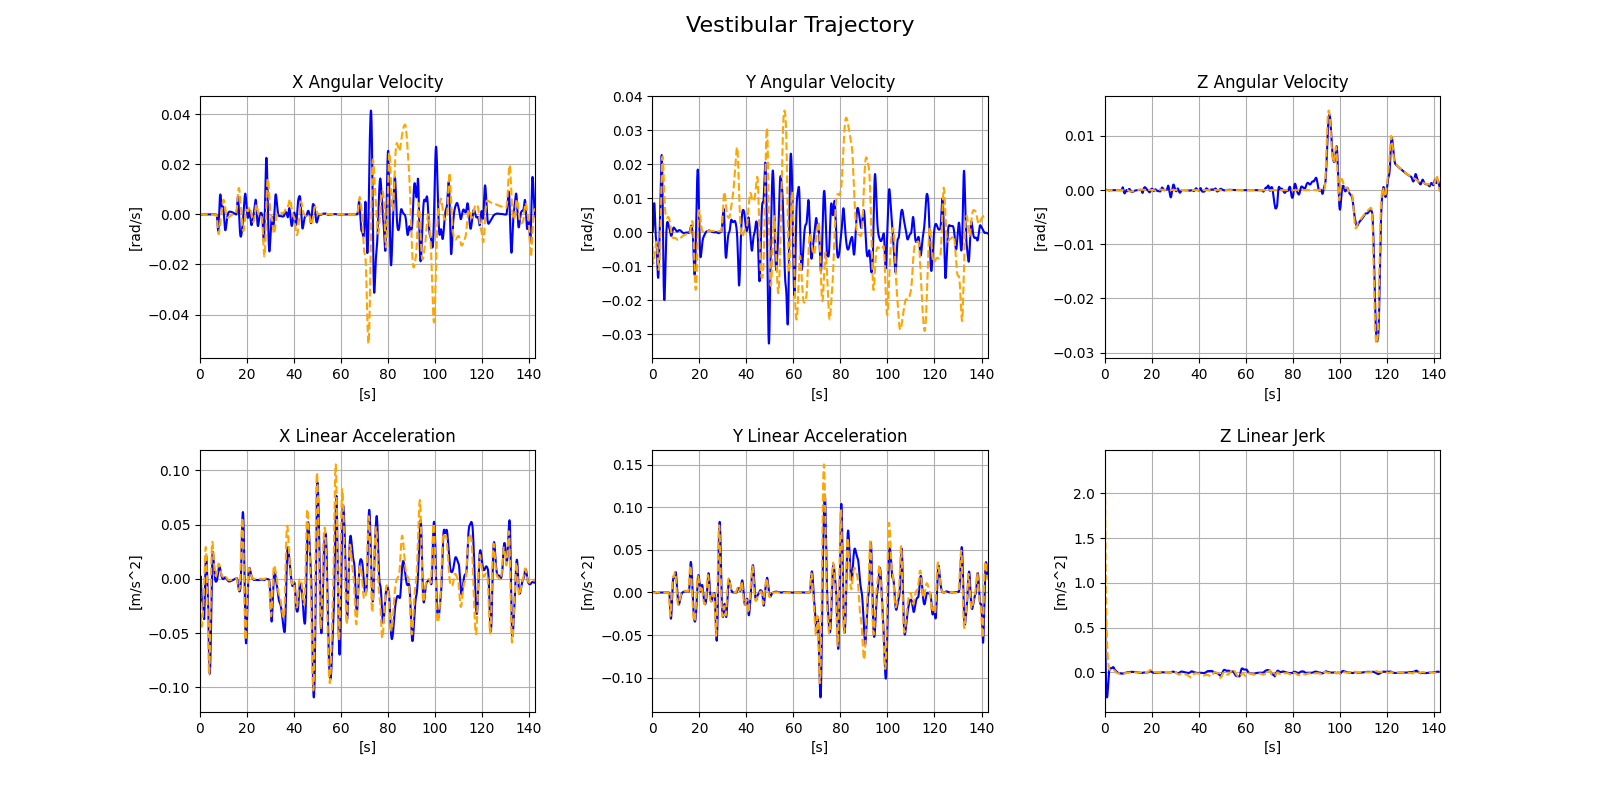

In [17]:
mpc_vestibular_fig = viz.plot_vestibular_trajectory(trajectory=trajectory, limits=limits, spec=spec)

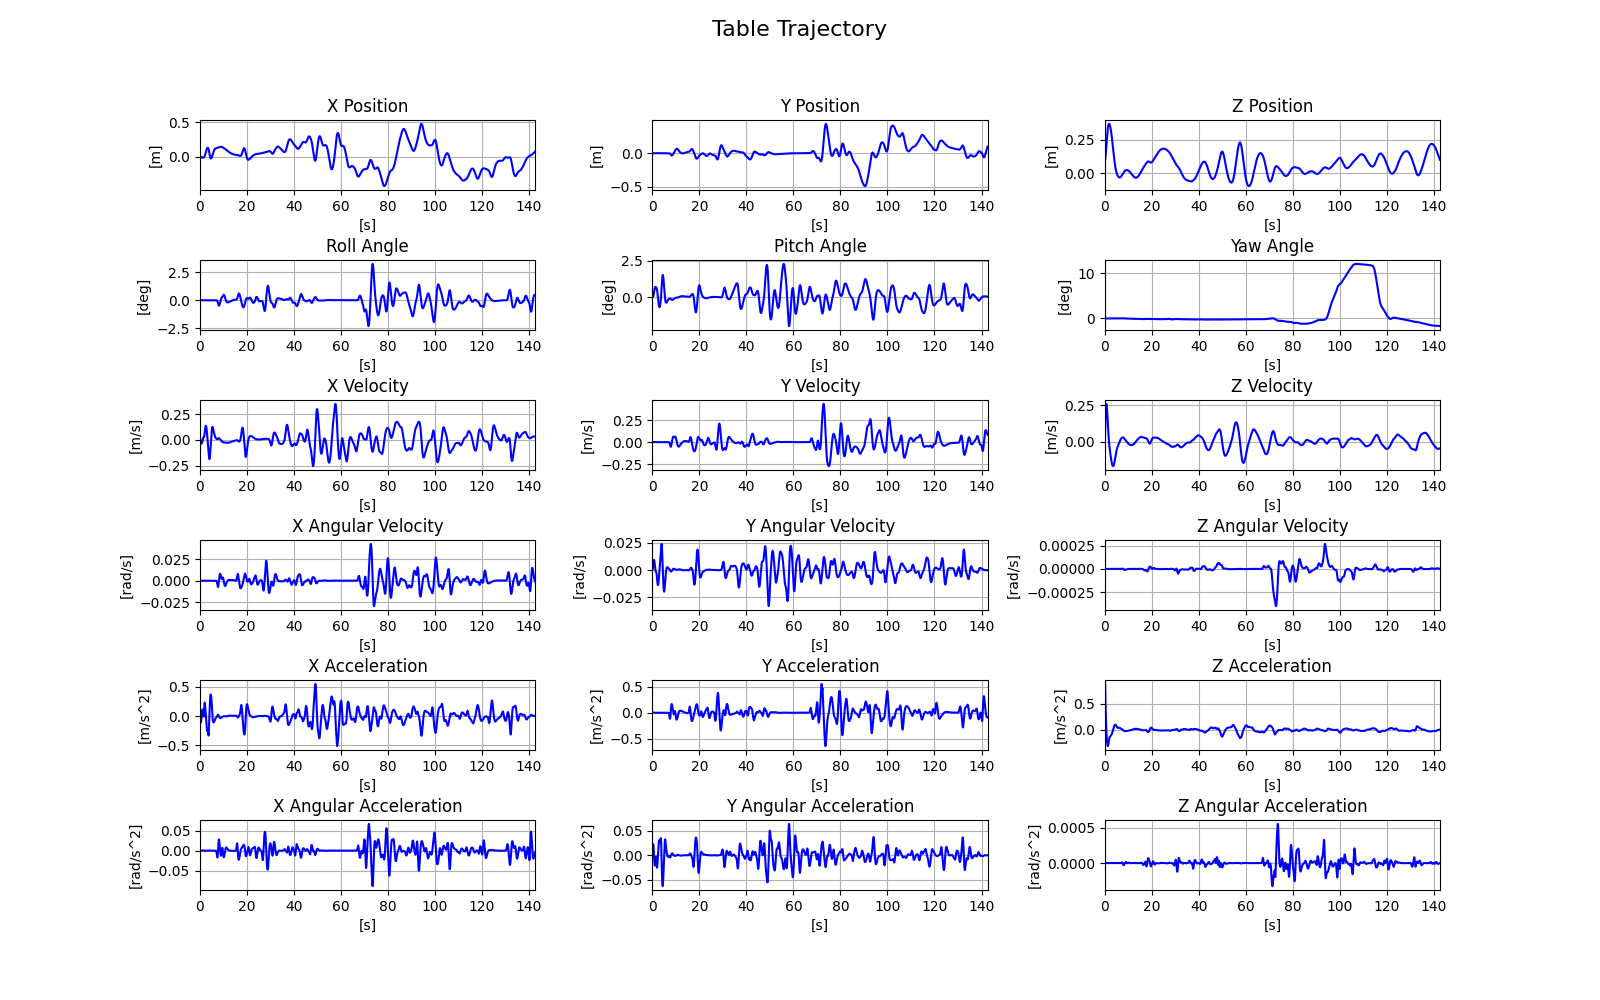

In [18]:
mpc_table_fig = viz.plot_cartesian_table_trajectory(trajectory=trajectory, limits=limits, spec=spec)

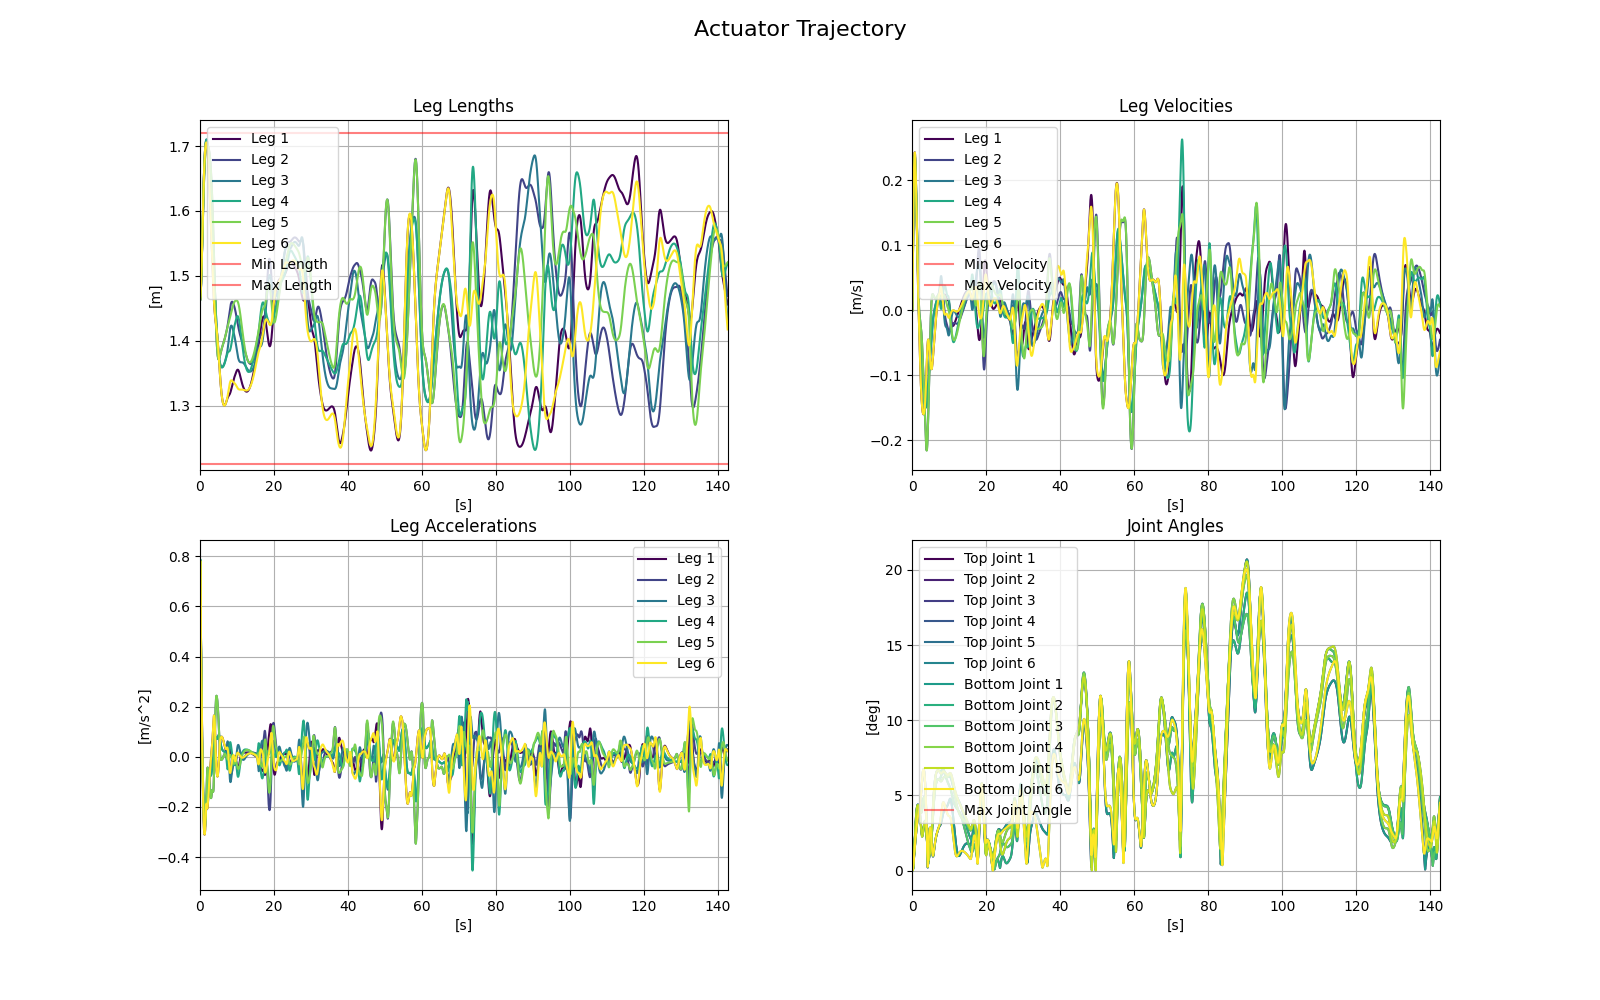

In [19]:
mpc_actuator_fig = viz.plot_actuator_trajectory(trajectory=trajectory, limits=limits, spec=spec)

In [20]:
assert False

AssertionError: 

## animations

(WARNING: can take a long time.
Usually about as long as the video being generated.)

In [ ]:
mp_mpl.call_mp_animate_trajectory(
    file_name="../data/sms_acc_3d.mp4",
    trajectory=trajectory,
    limits=limits,
    spec=spec,
)